In [36]:
import pandas
import os

In [37]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [38]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_lieux = []

for year in years:
    df_lieux_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"lieux-{year}.csv"), encoding="utf-8", sep = ";", dtype=str)
    df_lieux.append(df_lieux_year)

df_lieux = pandas.concat(df_lieux)
df_lieux

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,201900000001,1,3,0,NaN,3,10,0,1,6,900,2,NaN,NaN,1,2,1,70
1,201900000002,1,1,0,NaN,1,2,0,4,3,845,2,NaN,NaN,1,0,1,70
2,201900000003,1,86,0,NaN,3,8,0,1,10,500,3,NaN,NaN,1,0,1,90
3,201900000004,1,4,0,NaN,3,5,0,1,2,299,1,NaN,NaN,1,0,1,90
4,201900000005,1,86,0,INT,1,3,0,1,41,0,3,NaN,NaN,1,2,1,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70243,202400054398,3,NaN,-1,NaN,1,1,-1,1,-1,-1,1,NaN,-1,2,5,4,-1
70244,202400054399,3,RUE PIERRE GAUDIN,0,NaN,1,1,2,1,0,0,2,NaN,-1,1,0,1,30
70245,202400054400,2,12,0,NaN,1,2,0,2,31,1 000,1,NaN,10,1,0,1,110
70246,202400054401,3,JEAN JAURES (BOULEVARD) 63/215 - 70/208,0,NaN,2,3,0,1,0,0,1,NaN,"10,5",1,0,1,50


In [39]:
column_names_to_int = ['Num_Acc', 'catr', 'v1', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    )
)

In [40]:
df_lieux.replace(-1, pandas.NA, inplace=True)

for col in df_lieux.columns:
    prop = df_lieux[col].isna().sum() / len(df_lieux)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For catr proportion missing: 0.00%
For voie proportion missing: 13.67%
For v1 proportion missing: 20.02%
For v2 proportion missing: 91.91%
For circ proportion missing: 6.00%
For nbv proportion missing: 2.97%
For vosp proportion missing: 2.53%
For prof proportion missing: 0.08%
For pr proportion missing: 15.90%
For pr1 proportion missing: 15.97%
For plan proportion missing: 0.07%
For lartpc proportion missing: 99.84%
For larrout proportion missing: 86.00%
For surf proportion missing: 0.09%
For infra proportion missing: 1.10%
For situ proportion missing: 0.11%
For vma proportion missing: 3.23%


In [41]:
df_lieux.replace(-1, pandas.NA, inplace=True)

for col in df_lieux.columns:
    prop = df_lieux[col].isna().sum() / len(df_lieux)
    if (prop * 100 > 10):
        print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For voie proportion missing: 13.67%
For v1 proportion missing: 20.02%
For v2 proportion missing: 91.91%
For pr proportion missing: 15.90%
For pr1 proportion missing: 15.97%
For lartpc proportion missing: 99.84%
For larrout proportion missing: 86.00%


In [42]:
# First we are dropping features that we are not going to use
df_lieux.drop(columns = ['voie', 'v1', 'v2', 'pr', 'pr1', 'lartpc', 'larrout'], inplace = True)

In [43]:
# Removing rows with missing values
df_lieux = df_lieux.dropna()

# And converting to int
column_names_to_int = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma']

df_lieux[column_names_to_int] = df_lieux[column_names_to_int].astype("int64")

<Axes: xlabel='vma', ylabel='Count'>

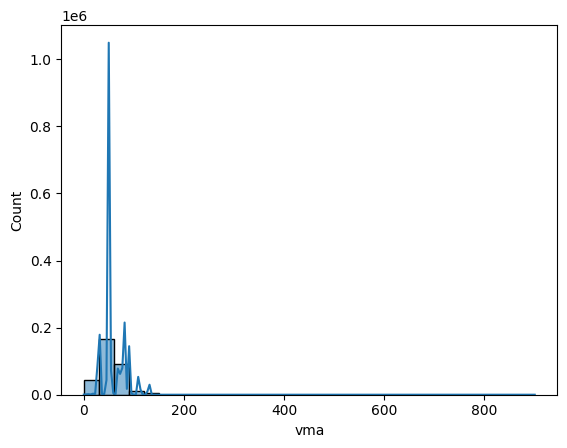

In [44]:
import seaborn as sns
sns.histplot(df_lieux["vma"], bins=30, kde=True)

In [45]:
df_lieux["vma"].value_counts()

vma
50     164618
80      46278
30      42046
90      23579
70      22700
110     10712
130      5925
60        870
20        752
40        330
10        273
25        152
45        104
15         93
5          82
500        61
2          53
100        52
1          33
35         17
6          15
3          13
300         9
900         6
4           5
700         5
75          5
65          3
55          3
0           2
12          2
800         2
8           2
7           2
140         2
120         1
42          1
600         1
520         1
901         1
9           1
501         1
502         1
770         1
31          1
85          1
95          1
16          1
301         1
Name: count, dtype: int64

In [46]:
valid_limits = [5,10,15,20,30,50,70,80,90,110,130]
df_lieux['vma'] = df_lieux['vma'].where(df_lieux['vma'].isin(valid_limits), None)

In [47]:
df_lieux['vma'].isna().sum()

np.int64(1762)

In [48]:
df_lieux = df_lieux.dropna()
df_lieux['vma'] = df_lieux['vma'].astype("int64")

In [49]:
features = column_names_to_int[:]
categorical_features = features[:]
numerical_features = []

In [50]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_lieux_with_target = df_lieux.merge(
    df_usagers[['Num_Acc', 'grav_bin']],
    on='Num_Acc',
    how='left'
)

target = "grav_bin"

In [57]:
df_lieux_with_target.isna().sum()

Num_Acc       0
catr          0
circ          0
nbv           0
vosp          0
prof          0
plan          0
surf          0
infra         0
situ          0
vma           0
grav_bin    209
dtype: int64

In [58]:
df_lieux_with_target = df_lieux_with_target.dropna()

In [59]:
df_lieux_analyse = df_lieux_with_target.copy() 

mapping = {
1: "Autoroute",  
2: "Route nationale",  
3: "Route Départementale",  
4: "Voie Communales",  
5: "Hors réseau public",  
6: "Parc de stationnement ",  
7: "Routes de métropole urbaine",  
9: "Autre" }
df_lieux_analyse["catr"] = df_lieux_analyse["catr"].replace(mapping)

mapping = {
1: "A sens unique",
2: "Bidirectionnelle",
3: "A chaussées séparées",
4: "Avec voies d’affectation variable" }
df_lieux_analyse["circ"] = df_lieux_analyse["circ"].replace(mapping)

# nbvp - ok

mapping = {
0: "Sans objet",
1: "Piste cyclable",
2: "Bande cyclable",
3: "Voie réservée"
}
df_lieux_analyse["vosp"] = df_lieux_analyse["vosp"].replace(mapping)

mapping = {
1: "Plat",  
2: "Pente",  
3: "Sommet de côte",  
4: "Bas de côte" }
df_lieux_analyse["prof"] = df_lieux_analyse["prof"].replace(mapping)

mapping = {
1: "Partie rectiligne",  
2: "En courbe à gauche",  
3: "En courbe à droite", 
4: "En « S »"}
df_lieux_analyse["plan"] = df_lieux_analyse["plan"].replace(mapping)

mapping = {
1: "Normale",   
2: "Mouillée",   
3: "Flaques",   
4: "Inondée",   
5: "Enneigée",   
6: "Boue",  
7: "Verglacée",   
8: "Corps gras – huile",   
9: "Autre"}
df_lieux_analyse["surf"] = df_lieux_analyse["surf"].replace(mapping)

mapping = {
0: "Aucun",   
1: "Souterrain - tunnel",  
2: "Pont - autopont",  
3: "Bretelle d’échangeur ou de raccordement",  
4: "Voie ferrée",  
5: "Carrefour aménagé",  
6: "Zone piétonne",  
7: "Zone de péage",  
8: "Chantier",  
9: "Autres" }
df_lieux_analyse["infra"] = df_lieux_analyse["infra"].replace(mapping)

mapping = {
0: "Aucun",
1: "Sur chaussée",  
2: "Sur bande d’arrêt d’urgence",  
3: "Sur accotement",  
4: "Sur trottoir",  
5: "Sur piste cyclable",  
6: "Sur autre voie spéciale",  
8: "Autres"}
df_lieux_analyse["situ"] = df_lieux_analyse["situ"].replace(mapping)

# vma - ok

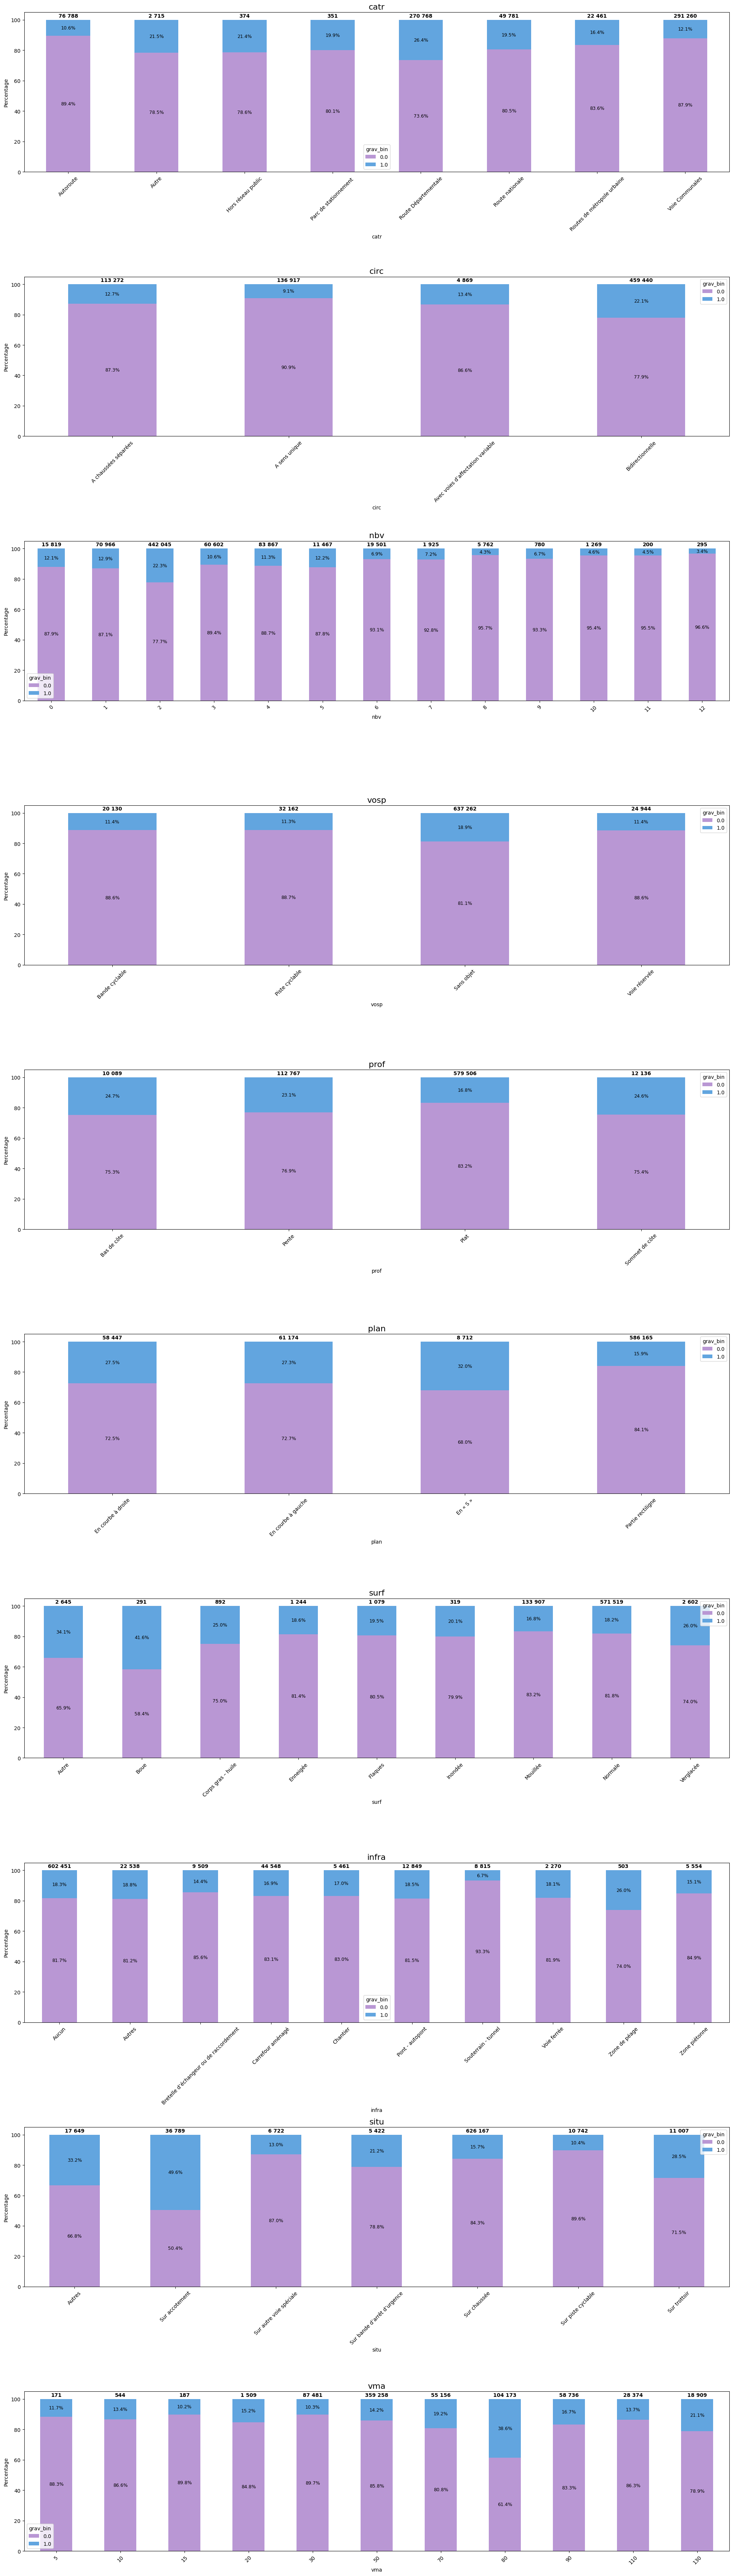

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

df_lieux_analyse = df_lieux_analyse.reset_index(drop=True)

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_lieux_analyse[feature],
        df_lieux_analyse[target],
        normalize="index"
    ) * 100

    counts = df_lieux_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

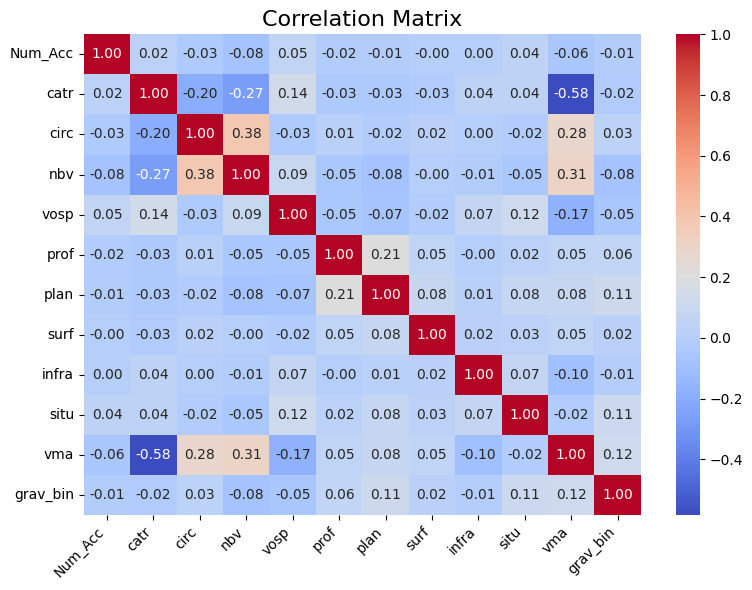

In [71]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_lieux_with_target.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_lieux_with_target[categorical_features + numerical_features]
y = df_lieux_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

In [64]:
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.8250244926522043

 Decision Tree
Accuracy: 0.8215885234429671

 Gradient Boosting
Accuracy: 0.8251714485654303


AUC of Logistic Regression: 0.714
AUC of Decision Tree: 0.695
AUC of Gradient Boosting: 0.716


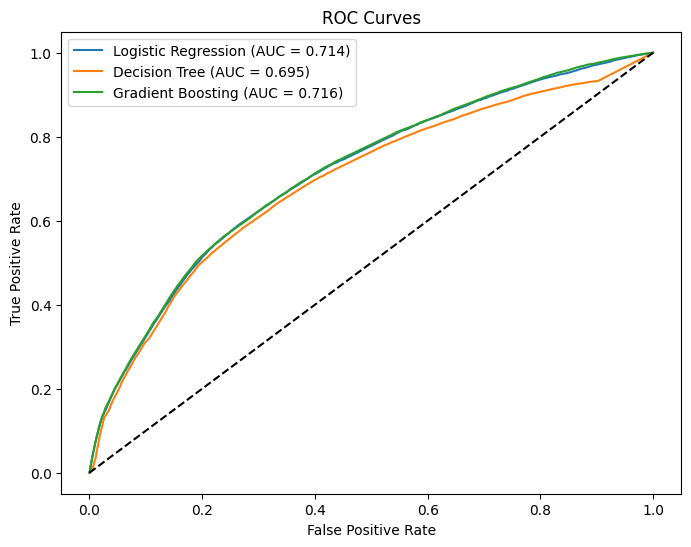

In [65]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [66]:
# Finally we are going to save the dataset cleaned
df_lieux.to_csv("df_lieux_clean.csv", index=False)

In [67]:
df_lieux = pandas.read_csv("df_lieux_clean.csv")

In [68]:
print("All columns:", df_lieux.columns)
print("Features:", features)

All columns: Index(['Num_Acc', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf',
       'infra', 'situ', 'vma'],
      dtype='str')
Features: ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf', 'infra', 'situ', 'vma']
